#AI4S INVESTMENT BANKING

---

##0.REFERENCE

https://claude.ai/share/8b0f3607-44cc-4907-99ba-b5e694ac7179

##1.CONTEXT



Wealth planning is, at its core, an optimisation problem under uncertainty. A
household arrives with income, assets, debts, and a set of ranked goals —
retirement security, college funding, a vacation property — and the task is to
find an investment strategy that maximises the probability of reaching all of
those goals within the constraints of their risk tolerance, time horizon, and
liquidity needs. That framing maps precisely onto the **AI for Science (AI4S)**
paradigm: a system that proposes candidate solutions, simulates their outcomes
across hundreds of possible futures, learns from scenarios where the strategy
fails, and refines its proposals accordingly. The market replaces the laboratory.
Monte Carlo paths replace experiments. Goal attainment probability replaces
reaction yield.

The critical difference from a standard financial model is the word *ranked*.
Most optimisers treat goals as interchangeable — maximise total expected wealth
subject to a risk constraint. Real clients do not experience their goals that way.
Retirement security is not the same kind of goal as a vacation home. One is
non-negotiable and carries thirty years of income dependency; the other is
aspirational and can be deferred or eliminated. A system that treats them
symmetrically will propose strategies that look efficient on paper but fail the
client in the scenario that actually matters most.

This notebook applies the AI4S framework to Sam and Taylor Reeves — a dual-income
household with a specific, non-trivial financial situation. Their total portfolio
stands at 1.33 million, but it has drifted badly: the taxable account is
concentrated in three technology stocks that represent over forty percent of that
account's value, 85,000 is sitting in a savings account earning fifty basis
points, Sam's 401k has not been rebalanced in three years and is almost certainly
over seventy percent equity, and both Roth IRA contribution streams were halted
two years ago. Against a retirement target of 3.6 million in fifteen years, a
college funding target of 640,000 in eight years, and a vacation home down
payment target of 195,000 in seven years, the baseline simulation shows a
weighted goal attainment probability that leaves significant room for improvement.
The gap is not hopeless. It is exactly the kind of problem that disciplined,
multi-period strategy can address — if the strategies are evaluated honestly.

The system has three components. `WealthStrategyLoop` runs one complete research
cycle: it generates candidate investment strategies via Claude, passes them through
a suitability gate that checks fiduciary compliance, runs 1,000 Monte Carlo
simulations of each strategy across a fifteen-year horizon, evaluates the
probability of meeting each ranked goal separately, stress-tests the best strategy
under a market crash, an inflation spike, and a sequence-of-returns scenario, and
produces a structured feedback diagnosis. `WealthEvaluationAgent` governs multiple
cycles, accumulating failure context between rounds and deciding whether to continue
searching or deploy the best plan found.

The third component is `AdvisorReviewAgent`, which simulates Robert Okafor, a
Senior Certified Financial Planner with twenty-two years of practice. Claude plays
Robert reviewing every AI recommendation before it can proceed. He asks three
questions that pure optimisation cannot answer: Is this strategy genuinely better
than doing nothing? Will Sam and Taylor actually stick to it behaviourally? Are
the fees justified relative to index alternatives? His review returns not just
modifications but also behavioural warnings — emotional and cognitive risks to flag
with the clients directly — and re-plan triggers specifying which life events should
prompt a full strategy review. These are professional judgment calls that belong to
the advisor, not the algorithm.

The suitability gate enforces the fiduciary standard before any strategy reaches
the simulation engine. A strategy that violates the concentration limit, recommends
illiquid products beyond the regulatory threshold, or proposes leverage for a
moderate-risk client is flagged as unsuitable and excluded. The simulation engine
never produces an expected-value number for an unsuitable strategy.

The market universe, asset class parameters, and regulatory rules used here are
synthetic. Nothing in this notebook constitutes investment advice or a solicitation
to buy or sell any security. Robert Okafor is a simulated persona. The purpose is
to show how the AI4S loop — propose, simulate, advise, decide — can operate in a
domain where numerical rigour and human judgment must work together, neither
replacing the other.




**Architecture**

```
DealEvaluationAgent  (governs up to 3 research cycles)
  |
  +--> AcquisitionStrategyLoop.run()  --> CycleResult
         |                                      |
         | generate target shortlist (Claude)   |
         | antitrust / regulatory screen        |
         | comparable transactions analysis     |
         | synergy model (revenue/cost/fin)     |
         | deal structure engine                |
         | stress test (integration/leverage)   |
         | accretion / dilution analysis        |
         | get feedback (Claude)                |
                                                |
  +--> MDReviewAgent.review()  <----------------+
         | Claude plays Victoria Sands,
         | Managing Director M&A
         | APPROVE / APPROVE_WITH_MODS / REJECT
         |
  +--> DealEvaluationAgent decides:
         CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS
```

| Cell | Content |
|------|---------|
| 1 | Setup |
| 2 | Synthetic deal universe (sector data, comps, regulatory rules) |
| 3 | Acquirer profile and strategic mandate |
| 4 | Target universe (10 candidate companies) |
| 5 | Valuation, synergy, and deal structure engines |
| 6 | `AcquisitionStrategyLoop` class |
| 7 | `MDReviewAgent` class |
| 8 | `DealEvaluationAgent` class |
| 9 | Orchestrator |
| 10 | Final deal recommendation dashboard |


---

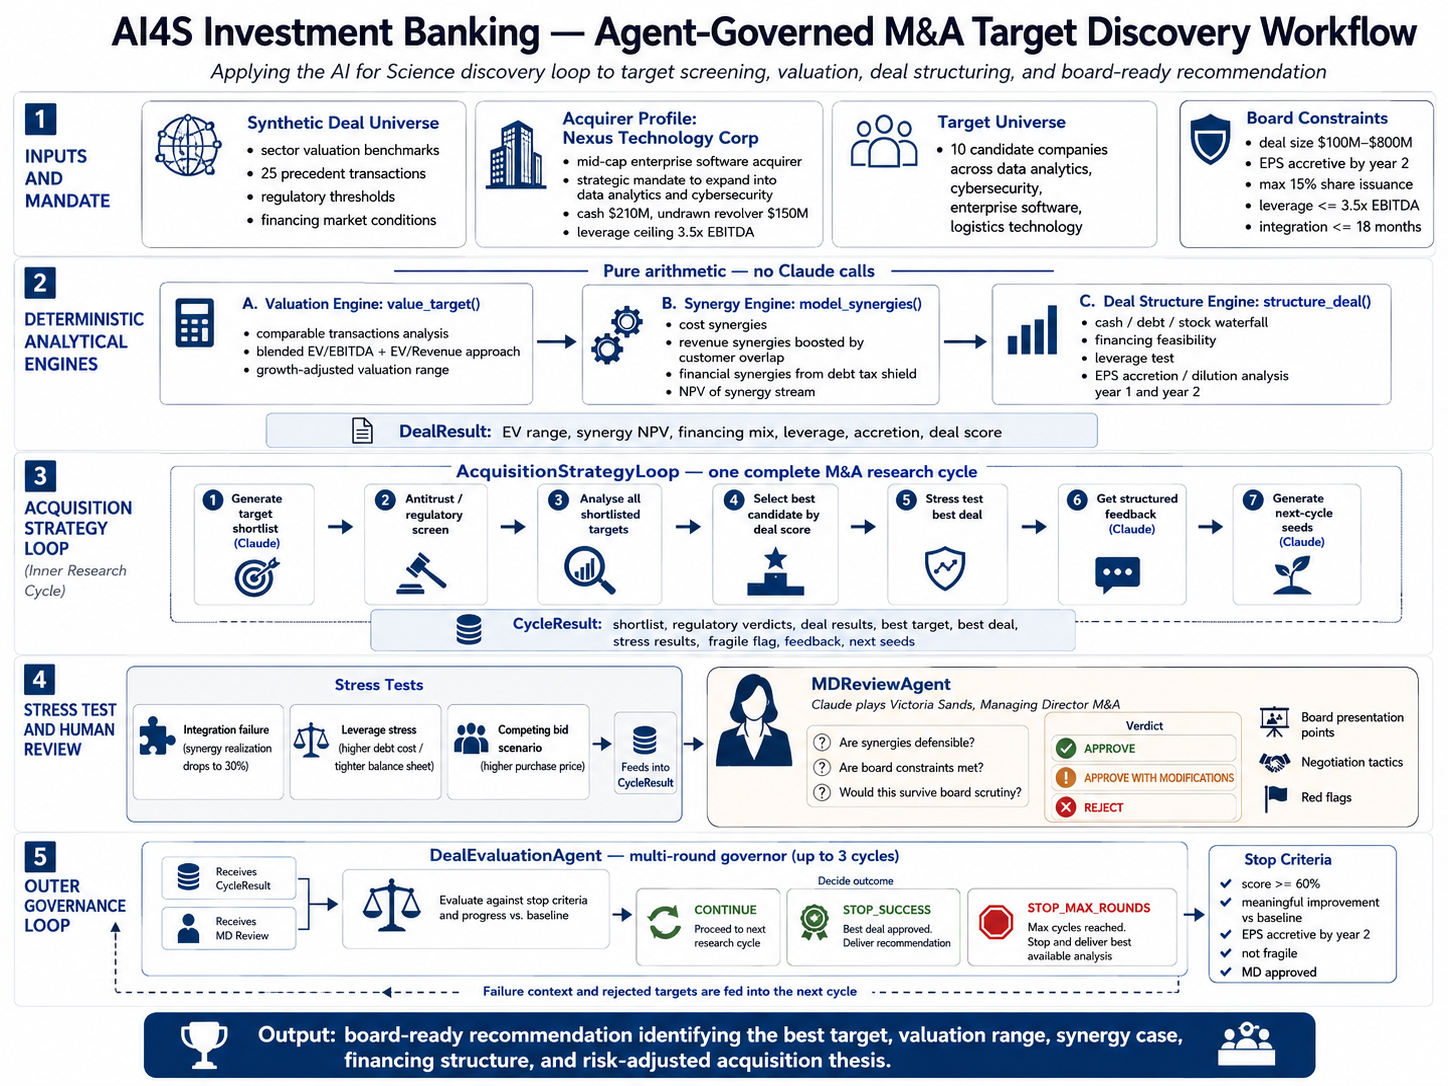

##2.CODE AND IMPLEMENTATION

In [2]:
# CELL 1  SETUP
# -----------------------------------------------------------------------
!pip install anthropic --quiet

import json, warnings
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import userdata
import anthropic

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25})

API_KEY = userdata.get('ANTHROPIC_API_KEY')
CLIENT  = anthropic.Anthropic(api_key=API_KEY)
MODEL   = 'claude-haiku-4-5-20251001'

def ask_claude(system, user, max_tokens=1200):
    msg = CLIENT.messages.create(
        model=MODEL, max_tokens=max_tokens,
        system=system,
        messages=[{'role': 'user', 'content': user}]
    )
    return msg.content[0].text.strip()

def parse_json(raw):
    clean = raw.strip().replace('```json','').replace('```','')
    return json.loads(clean.strip())

print('Setup complete -- model:', MODEL)

Setup complete -- model: claude-haiku-4-5-20251001


In [3]:
# CELL 2  SYNTHETIC DEAL UNIVERSE
# Sector valuation benchmarks, 25 precedent transactions,
# regulatory thresholds, and financing market conditions.
# -----------------------------------------------------------------------

DEAL_UNIVERSE = {
    'name': 'Synthetic M&A Market v1.0',
    'year': 2024,

    # -- Sector valuation benchmarks (EV / EBITDA medians) ---------------
    'sector_multiples': {
        'enterprise_software': {'ev_ebitda': 22.0, 'ev_rev': 6.5,  'pe': 38.0,
                                'growth_premium': 0.35},
        'data_analytics':      {'ev_ebitda': 18.5, 'ev_rev': 5.2,  'pe': 32.0,
                                'growth_premium': 0.28},
        'cybersecurity':       {'ev_ebitda': 25.0, 'ev_rev': 8.0,  'pe': 45.0,
                                'growth_premium': 0.40},
        'fintech':             {'ev_ebitda': 20.0, 'ev_rev': 7.0,  'pe': 35.0,
                                'growth_premium': 0.30},
        'healthtech':          {'ev_ebitda': 16.0, 'ev_rev': 4.8,  'pe': 28.0,
                                'growth_premium': 0.22},
        'cloud_infrastructure': {'ev_ebitda': 28.0,'ev_rev': 9.0,  'pe': 50.0,
                                'growth_premium': 0.45},
        'logistics_tech':      {'ev_ebitda': 14.0, 'ev_rev': 3.5,  'pe': 22.0,
                                'growth_premium': 0.15},
    },

    # -- M&A control premium benchmarks by sector -----------------------
    'control_premiums': {
        'enterprise_software':  0.32,
        'data_analytics':       0.28,
        'cybersecurity':        0.38,
        'fintech':              0.30,
        'healthtech':           0.25,
        'cloud_infrastructure': 0.42,
        'logistics_tech':       0.22,
    },

    # -- Financing market conditions ------------------------------------
    'financing': {
        'risk_free_rate':       0.045,
        'investment_grade_spread': 0.012,
        'leveraged_loan_spread':   0.045,
        'max_leverage_investment_grade': 3.0,   # x EBITDA
        'max_leverage_leveraged':       6.0,
        'equity_cost_of_capital':  0.095,
        'wacc_typical_range':   (0.072, 0.110),
    },

    # -- Synergy benchmarks by deal type --------------------------------
    'synergy_benchmarks': {
        'bolt_on':         {'cost_pct_target_rev': 0.12, 'rev_pct_combined': 0.04,
                            'realisation_yr': 2, 'success_rate': 0.75},
        'strategic_merge': {'cost_pct_target_rev': 0.18, 'rev_pct_combined': 0.08,
                            'realisation_yr': 3, 'success_rate': 0.60},
        'transformative':  {'cost_pct_target_rev': 0.08, 'rev_pct_combined': 0.15,
                            'realisation_yr': 4, 'success_rate': 0.45},
    },

    # -- Regulatory thresholds ------------------------------------------
    'regulatory': {
        'hsr_threshold_usd':       119_500_000,   # HSR filing required
        'hhi_concentration_floor': 1500,          # moderate concentration
        'hhi_concentration_high':  2500,          # high -- likely challenge
        'market_share_concern':    0.30,           # combined share triggers review
        'foreign_investment_review': True,         # CFIUS-equivalent
        'data_privacy_sectors': ['healthtech','fintech','data_analytics'],
    },

    # -- 25 precedent transactions --------------------------------------
    'precedent_deals': [
        # enterprise software
        {'id':'PD-001','sector':'enterprise_software','year':2022,
         'ev_ebitda_paid':24.5,'ev_rev_paid':7.2,'premium':0.34,
         'deal_type':'bolt_on','size_m':420,'synergy_realised':0.78,
         'integration_months':14,'outcome':'successful'},
        {'id':'PD-002','sector':'enterprise_software','year':2021,
         'ev_ebitda_paid':31.0,'ev_rev_paid':9.5,'premium':0.45,
         'deal_type':'transformative','size_m':2800,'synergy_realised':0.42,
         'integration_months':32,'outcome':'challenged'},
        {'id':'PD-003','sector':'enterprise_software','year':2023,
         'ev_ebitda_paid':19.8,'ev_rev_paid':5.8,'premium':0.28,
         'deal_type':'bolt_on','size_m':185,'synergy_realised':0.85,
         'integration_months':10,'outcome':'successful'},
        # data analytics
        {'id':'PD-004','sector':'data_analytics','year':2022,
         'ev_ebitda_paid':20.2,'ev_rev_paid':6.1,'premium':0.31,
         'deal_type':'strategic_merge','size_m':650,'synergy_realised':0.65,
         'integration_months':18,'outcome':'successful'},
        {'id':'PD-005','sector':'data_analytics','year':2020,
         'ev_ebitda_paid':16.8,'ev_rev_paid':4.5,'premium':0.24,
         'deal_type':'bolt_on','size_m':290,'synergy_realised':0.72,
         'integration_months':12,'outcome':'successful'},
        {'id':'PD-006','sector':'data_analytics','year':2023,
         'ev_ebitda_paid':22.5,'ev_rev_paid':7.0,'premium':0.36,
         'deal_type':'strategic_merge','size_m':1100,'synergy_realised':0.55,
         'integration_months':24,'outcome':'successful'},
        # cybersecurity
        {'id':'PD-007','sector':'cybersecurity','year':2022,
         'ev_ebitda_paid':28.0,'ev_rev_paid':9.2,'premium':0.40,
         'deal_type':'bolt_on','size_m':380,'synergy_realised':0.80,
         'integration_months':11,'outcome':'successful'},
        {'id':'PD-008','sector':'cybersecurity','year':2021,
         'ev_ebitda_paid':35.0,'ev_rev_paid':12.0,'premium':0.52,
         'deal_type':'transformative','size_m':4500,'synergy_realised':0.38,
         'integration_months':36,'outcome':'challenged'},
        {'id':'PD-009','sector':'cybersecurity','year':2023,
         'ev_ebitda_paid':26.5,'ev_rev_paid':8.5,'premium':0.37,
         'deal_type':'strategic_merge','size_m':820,'synergy_realised':0.70,
         'integration_months':16,'outcome':'successful'},
        # fintech
        {'id':'PD-010','sector':'fintech','year':2022,
         'ev_ebitda_paid':22.0,'ev_rev_paid':7.5,'premium':0.33,
         'deal_type':'bolt_on','size_m':510,'synergy_realised':0.68,
         'integration_months':15,'outcome':'successful'},
        {'id':'PD-011','sector':'fintech','year':2020,
         'ev_ebitda_paid':18.5,'ev_rev_paid':6.0,'premium':0.27,
         'deal_type':'strategic_merge','size_m':740,'synergy_realised':0.60,
         'integration_months':20,'outcome':'successful'},
        {'id':'PD-012','sector':'fintech','year':2023,
         'ev_ebitda_paid':24.0,'ev_rev_paid':8.2,'premium':0.38,
         'deal_type':'bolt_on','size_m':260,'synergy_realised':0.82,
         'integration_months':9,'outcome':'successful'},
        # healthtech
        {'id':'PD-013','sector':'healthtech','year':2022,
         'ev_ebitda_paid':17.5,'ev_rev_paid':5.2,'premium':0.28,
         'deal_type':'bolt_on','size_m':330,'synergy_realised':0.71,
         'integration_months':13,'outcome':'successful'},
        {'id':'PD-014','sector':'healthtech','year':2021,
         'ev_ebitda_paid':14.0,'ev_rev_paid':4.0,'premium':0.20,
         'deal_type':'strategic_merge','size_m':880,'synergy_realised':0.55,
         'integration_months':22,'outcome':'successful'},
        {'id':'PD-015','sector':'healthtech','year':2023,
         'ev_ebitda_paid':19.0,'ev_rev_paid':5.8,'premium':0.32,
         'deal_type':'bolt_on','size_m':195,'synergy_realised':0.76,
         'integration_months':11,'outcome':'successful'},
        # cloud infrastructure
        {'id':'PD-016','sector':'cloud_infrastructure','year':2022,
         'ev_ebitda_paid':30.0,'ev_rev_paid':10.5,'premium':0.44,
         'deal_type':'strategic_merge','size_m':1850,'synergy_realised':0.62,
         'integration_months':21,'outcome':'successful'},
        {'id':'PD-017','sector':'cloud_infrastructure','year':2021,
         'ev_ebitda_paid':38.0,'ev_rev_paid':13.0,'premium':0.55,
         'deal_type':'transformative','size_m':6200,'synergy_realised':0.35,
         'integration_months':40,'outcome':'challenged'},
        {'id':'PD-018','sector':'cloud_infrastructure','year':2023,
         'ev_ebitda_paid':27.0,'ev_rev_paid':9.2,'premium':0.40,
         'deal_type':'bolt_on','size_m':420,'synergy_realised':0.79,
         'integration_months':12,'outcome':'successful'},
        # logistics tech
        {'id':'PD-019','sector':'logistics_tech','year':2022,
         'ev_ebitda_paid':15.0,'ev_rev_paid':3.8,'premium':0.24,
         'deal_type':'bolt_on','size_m':280,'synergy_realised':0.73,
         'integration_months':10,'outcome':'successful'},
        {'id':'PD-020','sector':'logistics_tech','year':2023,
         'ev_ebitda_paid':13.5,'ev_rev_paid':3.2,'premium':0.20,
         'deal_type':'strategic_merge','size_m':450,'synergy_realised':0.64,
         'integration_months':16,'outcome':'successful'},
        # cross-sector / failed
        {'id':'PD-021','sector':'fintech','year':2020,
         'ev_ebitda_paid':28.0,'ev_rev_paid':10.0,'premium':0.48,
         'deal_type':'transformative','size_m':3200,'synergy_realised':0.22,
         'integration_months':48,'outcome':'failed'},
        {'id':'PD-022','sector':'data_analytics','year':2021,
         'ev_ebitda_paid':25.0,'ev_rev_paid':8.0,'premium':0.40,
         'deal_type':'transformative','size_m':1600,'synergy_realised':0.30,
         'integration_months':38,'outcome':'challenged'},
        {'id':'PD-023','sector':'enterprise_software','year':2023,
         'ev_ebitda_paid':18.0,'ev_rev_paid':5.0,'premium':0.25,
         'deal_type':'bolt_on','size_m':95,'synergy_realised':0.90,
         'integration_months':8,'outcome':'successful'},
        {'id':'PD-024','sector':'cybersecurity','year':2022,
         'ev_ebitda_paid':22.0,'ev_rev_paid':7.0,'premium':0.30,
         'deal_type':'strategic_merge','size_m':580,'synergy_realised':0.74,
         'integration_months':17,'outcome':'successful'},
        {'id':'PD-025','sector':'healthtech','year':2020,
         'ev_ebitda_paid':21.0,'ev_rev_paid':6.5,'premium':0.35,
         'deal_type':'strategic_merge','size_m':720,'synergy_realised':0.58,
         'integration_months':19,'outcome':'successful'},
    ],
}

n_deals = len(DEAL_UNIVERSE['precedent_deals'])
success  = sum(1 for d in DEAL_UNIVERSE['precedent_deals'] if d['outcome']=='successful')
print(f'Deal universe loaded:')
print(f'  Sectors            : {len(DEAL_UNIVERSE["sector_multiples"])}')
print(f'  Precedent deals    : {n_deals}  ({success} successful, {n_deals-success} challenged/failed)')
print(f'  Avg synergy realised: '
      f'{np.mean([d["synergy_realised"] for d in DEAL_UNIVERSE["precedent_deals"]]):.0%}')

Deal universe loaded:
  Sectors            : 7
  Precedent deals    : 25  (20 successful, 5 challenged/failed)
  Avg synergy realised: 63%


In [4]:
# CELL 3  ACQUIRER PROFILE AND STRATEGIC MANDATE
# Nexus Technology Corp -- a mid-cap enterprise software company
# seeking to expand into data analytics and cybersecurity.
# -----------------------------------------------------------------------

ACQUIRER = {
    'name':             'Nexus Technology Corp',
    'ticker':           'NXTC',
    'sector':           'enterprise_software',
    'description':      'Mid-cap provider of ERP and workflow automation '
                        'software for mid-market manufacturing clients.',

    # -- Financials (trailing twelve months) ----------------------------
    'revenue':          580_000_000,
    'ebitda':            98_000_000,
    'ebit':              74_000_000,
    'net_income':        52_000_000,
    'free_cash_flow':    61_000_000,
    'revenue_growth':    0.14,          # 14% YoY
    'ebitda_margin':     0.169,
    'net_debt':         120_000_000,
    'market_cap':      1_850_000_000,
    'enterprise_value': 1_970_000_000,
    'shares_out':        74_000_000,
    'stock_price':        25.00,
    'eps':                 0.70,
    'pe_ratio':           35.7,

    # -- Balance sheet capacity -----------------------------------------
    'cash_on_hand':      210_000_000,
    'undrawn_revolver':  150_000_000,
    'leverage_current':    1.22,        # net debt / EBITDA
    'leverage_max_comfort': 3.50,       # board-approved ceiling
    'credit_rating':    'BBB+',

    # -- Strategic mandate ----------------------------------------------
    'strategic_mandate': (
        'Nexus seeks to acquire a data analytics or cybersecurity platform '
        'that deepens product stickiness within its existing manufacturing '
        'client base, accelerates ARR growth toward $800M by 2027, and '
        'expands addressable market into financial services.'
    ),
    'target_sectors':   ['data_analytics', 'cybersecurity', 'enterprise_software'],
    'deal_size_range':  (100_000_000, 800_000_000),   # USD
    'preferred_deal_type': 'bolt_on',
    'accretion_required': True,         # must be EPS accretive by year 2
    'max_dilution_pct':   0.15,         # max share issuance vs shares out

    # -- Integration capacity -------------------------------------------
    'integration_capacity': 'moderate',  # one deal at a time, max 18 months
    'prior_acquisitions':   2,
    'avg_prior_integration_months': 16,

    # -- Board constraints ----------------------------------------------
    'board_constraints': [
        'No deals > $800M without special shareholder vote.',
        'Must remain investment-grade (leverage <= 3.5x EBITDA).',
        'EPS accretion required by fiscal year 2 post-close.',
        'No cross-border deals exceeding 30% of combined revenue.',
        'Integration timeline must not exceed 18 months.',
    ],
}

print(f'Acquirer         : {ACQUIRER["name"]} ({ACQUIRER["ticker"]})')
print(f'Market cap       : ${ACQUIRER["market_cap"]/1e9:.2f}B')
print(f'Enterprise value : ${ACQUIRER["enterprise_value"]/1e9:.2f}B')
print(f'Revenue / EBITDA : ${ACQUIRER["revenue"]/1e6:.0f}M / ${ACQUIRER["ebitda"]/1e6:.0f}M')
print(f'Cash available   : ${ACQUIRER["cash_on_hand"]/1e6:.0f}M')
print(f'Max deal size    : ${ACQUIRER["deal_size_range"][1]/1e6:.0f}M')
print(f'Target sectors   : {ACQUIRER["target_sectors"]}')
print(f'\nStrategic mandate: {ACQUIRER["strategic_mandate"][:80]}...')

Acquirer         : Nexus Technology Corp (NXTC)
Market cap       : $1.85B
Enterprise value : $1.97B
Revenue / EBITDA : $580M / $98M
Cash available   : $210M
Max deal size    : $800M
Target sectors   : ['data_analytics', 'cybersecurity', 'enterprise_software']

Strategic mandate: Nexus seeks to acquire a data analytics or cybersecurity platform that deepens p...


In [5]:
# CELL 4  TARGET UNIVERSE
# 10 candidate companies across target sectors.
# Each has financials, ownership, and strategic fit notes.
# -----------------------------------------------------------------------

TARGET_UNIVERSE = [
    {
        'id': 'TGT-001', 'name': 'DataPulse Analytics',
        'sector': 'data_analytics',
        'description': 'Real-time operational analytics platform for '
                       'manufacturing and supply chain clients. '
                       'Strong customer overlap with Nexus.',
        'revenue': 88_000_000, 'revenue_growth': 0.28,
        'ebitda':  18_000_000, 'ebitda_margin': 0.205,
        'arr':     72_000_000, 'arr_growth': 0.32,
        'net_debt': 8_000_000,
        'ownership': 'private_equity',  # PE-backed, likely for sale
        'employees': 310,
        'customer_overlap_pct': 0.38,   # with Nexus customer base
        'technology_fit': 'high',
        'market_share': 0.06,
        'asking_price': None,           # not formally marketed
        'strategic_notes': 'Strong cultural fit. PE sponsor looking to exit.'
    },
    {
        'id': 'TGT-002', 'name': 'ShieldLayer Cybersecurity',
        'sector': 'cybersecurity',
        'description': 'Zero-trust network security for mid-market '
                       'industrial clients. Adjacent customer base.',
        'revenue': 62_000_000, 'revenue_growth': 0.41,
        'ebitda':   8_500_000, 'ebitda_margin': 0.137,
        'arr':     58_000_000, 'arr_growth': 0.45,
        'net_debt': 2_000_000,
        'ownership': 'venture_backed',
        'employees': 220,
        'customer_overlap_pct': 0.22,
        'technology_fit': 'medium',
        'market_share': 0.03,
        'asking_price': None,
        'strategic_notes': 'Fast-growing. Founders may want exit post-Series C.'
    },
    {
        'id': 'TGT-003', 'name': 'Meridian Data Systems',
        'sector': 'data_analytics',
        'description': 'Batch analytics and reporting for financial '
                       'services. Limited manufacturing exposure.',
        'revenue': 145_000_000, 'revenue_growth': 0.09,
        'ebitda':  31_000_000,  'ebitda_margin': 0.214,
        'arr':     110_000_000, 'arr_growth': 0.11,
        'net_debt': 45_000_000,
        'ownership': 'public',
        'employees': 680,
        'customer_overlap_pct': 0.08,
        'technology_fit': 'low',
        'market_share': 0.11,
        'asking_price': None,
        'strategic_notes': 'Larger platform but limited strategic overlap. '
                           'Slower growth. Premium required to go private.'
    },
    {
        'id': 'TGT-004', 'name': 'VaultGuard Security',
        'sector': 'cybersecurity',
        'description': 'OT/ICS security specialist for manufacturing '
                       'and critical infrastructure. Perfect sector fit.',
        'revenue': 44_000_000, 'revenue_growth': 0.55,
        'ebitda':   4_200_000, 'ebitda_margin': 0.095,
        'arr':     40_000_000, 'arr_growth': 0.60,
        'net_debt': -3_000_000,  # net cash
        'ownership': 'venture_backed',
        'employees': 145,
        'customer_overlap_pct': 0.44,
        'technology_fit': 'very_high',
        'market_share': 0.02,
        'asking_price': None,
        'strategic_notes': 'Very high fit. Nascent but fast. Low EBITDA '
                           'makes traditional valuation challenging.'
    },
    {
        'id': 'TGT-005', 'name': 'Operant Analytics',
        'sector': 'data_analytics',
        'description': 'AI-powered predictive maintenance analytics '
                       'for industrial equipment. High NPS, sticky ARR.',
        'revenue': 118_000_000, 'revenue_growth': 0.22,
        'ebitda':  24_000_000,  'ebitda_margin': 0.203,
        'arr':     98_000_000,  'arr_growth': 0.25,
        'net_debt': 15_000_000,
        'ownership': 'private_equity',
        'employees': 420,
        'customer_overlap_pct': 0.52,
        'technology_fit': 'very_high',
        'market_share': 0.08,
        'asking_price': 480_000_000,   # PE running a formal process
        'strategic_notes': 'Formal auction process underway. '
                           'Multiple strategic and financial bidders.'
    },
    {
        'id': 'TGT-006', 'name': 'CloudSync Enterprise',
        'sector': 'enterprise_software',
        'description': 'Cloud migration and integration middleware. '
                       'Complementary to Nexus ERP suite.',
        'revenue': 76_000_000, 'revenue_growth': 0.18,
        'ebitda':  16_000_000, 'ebitda_margin': 0.211,
        'arr':     64_000_000, 'arr_growth': 0.20,
        'net_debt': 5_000_000,
        'ownership': 'private_equity',
        'employees': 280,
        'customer_overlap_pct': 0.29,
        'technology_fit': 'high',
        'market_share': 0.05,
        'asking_price': None,
        'strategic_notes': 'Clean bolt-on. ERP integration story is clear.'
    },
    {
        'id': 'TGT-007', 'name': 'Prism Data Intelligence',
        'sector': 'data_analytics',
        'description': 'Advanced ML-based demand forecasting platform. '
                       'Primarily serves retail and CPG sectors.',
        'revenue': 52_000_000, 'revenue_growth': 0.35,
        'ebitda':   7_800_000, 'ebitda_margin': 0.150,
        'arr':     48_000_000, 'arr_growth': 0.38,
        'net_debt': 12_000_000,
        'ownership': 'venture_backed',
        'employees': 190,
        'customer_overlap_pct': 0.11,
        'technology_fit': 'medium',
        'market_share': 0.04,
        'asking_price': None,
        'strategic_notes': 'Good technology but wrong vertical. '
                           'Customer base does not overlap with Nexus.'
    },
    {
        'id': 'TGT-008', 'name': 'NeuralOps Platform',
        'sector': 'data_analytics',
        'description': 'Autonomous operations AI for discrete manufacturing. '
                       'Direct adjacency to Nexus ERP workflow module.',
        'revenue': 38_000_000, 'revenue_growth': 0.48,
        'ebitda':   3_200_000, 'ebitda_margin': 0.084,
        'arr':     35_000_000, 'arr_growth': 0.52,
        'net_debt': -8_000_000,  # net cash
        'ownership': 'venture_backed',
        'employees': 130,
        'customer_overlap_pct': 0.61,
        'technology_fit': 'very_high',
        'market_share': 0.03,
        'asking_price': None,
        'strategic_notes': 'Highest customer overlap in universe. '
                           'Small but extremely fast-growing.'
    },
    {
        'id': 'TGT-009', 'name': 'Fortis Cyber Defense',
        'sector': 'cybersecurity',
        'description': 'Compliance automation and GRC platform '
                       'for regulated manufacturing industries.',
        'revenue': 95_000_000, 'revenue_growth': 0.19,
        'ebitda':  22_000_000, 'ebitda_margin': 0.232,
        'arr':     88_000_000, 'arr_growth': 0.21,
        'net_debt': 18_000_000,
        'ownership': 'private_equity',
        'employees': 380,
        'customer_overlap_pct': 0.33,
        'technology_fit': 'high',
        'market_share': 0.05,
        'asking_price': None,
        'strategic_notes': 'Solid EBITDA margins. Regulatory tailwinds '
                           'from new manufacturing compliance requirements.'
    },
    {
        'id': 'TGT-010', 'name': 'Axiom Supply Chain AI',
        'sector': 'logistics_tech',
        'description': 'AI-driven supply chain visibility and '
                       'optimisation for Tier 1 manufacturers.',
        'revenue': 68_000_000, 'revenue_growth': 0.24,
        'ebitda':  11_500_000, 'ebitda_margin': 0.169,
        'arr':     58_000_000, 'arr_growth': 0.26,
        'net_debt': 9_000_000,
        'ownership': 'private_equity',
        'employees': 245,
        'customer_overlap_pct': 0.41,
        'technology_fit': 'high',
        'market_share': 0.04,
        'asking_price': None,
        'strategic_notes': 'Supply chain adjacency to ERP. '
                           'Lower valuation multiple vs software peers.'
    },
]

print(f'Target universe: {len(TARGET_UNIVERSE)} candidates')
print(f'\n{"ID":8s} {"Name":30s} {"Sector":22s} {"Rev $M":>8s} {"EBITDA%":>8s} {"Fit":>10s} {"Overlap":>8s}')
print('-'*100)
for t in TARGET_UNIVERSE:
    print(f'{t["id"]:8s} {t["name"][:28]:30s} {t["sector"]:22s} '
          f'{t["revenue"]/1e6:>8.0f} {t["ebitda_margin"]:>8.1%} '
          f'{t["technology_fit"]:>10s} {t["customer_overlap_pct"]:>8.0%}')

Target universe: 10 candidates

ID       Name                           Sector                   Rev $M  EBITDA%        Fit  Overlap
----------------------------------------------------------------------------------------------------
TGT-001  DataPulse Analytics            data_analytics               88    20.5%       high      38%
TGT-002  ShieldLayer Cybersecurity      cybersecurity                62    13.7%     medium      22%
TGT-003  Meridian Data Systems          data_analytics              145    21.4%        low       8%
TGT-004  VaultGuard Security            cybersecurity                44     9.5%  very_high      44%
TGT-005  Operant Analytics              data_analytics              118    20.3%  very_high      52%
TGT-006  CloudSync Enterprise           enterprise_software          76    21.1%       high      29%
TGT-007  Prism Data Intelligence        data_analytics               52    15.0%     medium      11%
TGT-008  NeuralOps Platform             data_analytics     

In [6]:
# CELL 5  VALUATION, SYNERGY, AND DEAL STRUCTURE ENGINES
# Pure arithmetic -- no Claude calls.
# -----------------------------------------------------------------------

@dataclass
class DealResult:
    target_id:           str   = ''
    target_name:         str   = ''
    sector:              str   = ''
    comparable_deals:    list  = field(default_factory=list)
    # valuation
    ev_low:              float = 0.0
    ev_mid:              float = 0.0
    ev_high:             float = 0.0
    implied_ev_ebitda:   float = 0.0
    implied_ev_rev:      float = 0.0
    control_premium:     float = 0.0
    # synergies
    cost_synergies:      float = 0.0
    rev_synergies:       float = 0.0
    financial_synergies: float = 0.0
    total_synergies:     float = 0.0
    synergy_realisation: float = 0.0
    synergy_npv:         float = 0.0
    # deal structure
    cash_component:      float = 0.0
    stock_component:     float = 0.0
    earnout_component:   float = 0.0
    leverage_ratio:      float = 0.0
    new_debt:            float = 0.0
    shares_issued:       float = 0.0
    dilution_pct:        float = 0.0
    # accretion / dilution
    eps_accretion_yr1:   float = 0.0
    eps_accretion_yr2:   float = 0.0
    accretive_yr2:       bool  = False
    # composite score
    strategic_fit_score: float = 0.0
    deal_score:          float = 0.0
    risk_flags:          list  = field(default_factory=list)
    notes:               list  = field(default_factory=list)


def find_comps(sector, size_m, n=4):
    comps = [d for d in DEAL_UNIVERSE['precedent_deals']
             if d['sector'] == sector
             and abs(d['size_m'] - size_m) / max(size_m, 1) < 2.0]
    if len(comps) < 2:
        comps = [d for d in DEAL_UNIVERSE['precedent_deals']
                 if d['sector'] == sector]
    return sorted(comps, key=lambda x: abs(x['size_m']-size_m))[:n]


def value_target(target):
    sec      = target['sector']
    bench    = DEAL_UNIVERSE['sector_multiples'].get(sec, {})
    ev_ebitda= bench.get('ev_ebitda', 15.0)
    ev_rev   = bench.get('ev_rev', 4.0)
    growth_p = bench.get('growth_premium', 0.20)
    control  = DEAL_UNIVERSE['control_premiums'].get(sec, 0.28)

    # growth-adjusted multiple
    growth_adj = 1 + (target['revenue_growth'] - 0.15) * growth_p
    ev_ebitda_adj = ev_ebitda * growth_adj
    ev_rev_adj    = ev_rev    * growth_adj

    # comparable deal anchor
    est_size = target['revenue'] * ev_rev_adj
    comps    = find_comps(sec, est_size / 1e6)
    if comps:
        comp_ev_ebitda = np.mean([c['ev_ebitda_paid'] for c in comps])
        comp_ev_rev    = np.mean([c['ev_rev_paid']    for c in comps])
        ev_ebitda_adj  = (ev_ebitda_adj + comp_ev_ebitda) / 2
        ev_rev_adj     = (ev_rev_adj    + comp_ev_rev)    / 2

    # intrinsic valuation range
    ebitda_val = target['ebitda'] * ev_ebitda_adj
    rev_val    = target['revenue'] * ev_rev_adj
    base_val   = (ebitda_val + rev_val) / 2
    net_debt   = target.get('net_debt', 0)

    ev_low  = base_val * 0.88 + net_debt
    ev_mid  = base_val        + net_debt
    ev_high = base_val * 1.15 * (1 + control) + net_debt

    return ev_low, ev_mid, ev_high, ev_ebitda_adj, ev_rev_adj, control, comps


def model_synergies(target, deal_type='bolt_on'):
    bench = DEAL_UNIVERSE['synergy_benchmarks'].get(deal_type, {})
    acq   = ACQUIRER
    comb_rev = acq['revenue'] + target['revenue']

    cost_syn  = target['revenue'] * bench.get('cost_pct_target_rev', 0.12)
    rev_syn   = comb_rev          * bench.get('rev_pct_combined',    0.04)
    # financial synergy -- tax shield on new debt
    fin_syn   = target.get('net_debt', 0) * 0.08 * 0.28  # simplified
    total_syn = cost_syn + rev_syn + fin_syn

    # customer overlap boosts revenue synergy
    overlap_boost = target.get('customer_overlap_pct', 0) * 0.50
    rev_syn *= (1 + overlap_boost)
    total_syn = cost_syn + rev_syn + fin_syn

    # realisation probability from comps
    comps   = find_comps(target['sector'], target['revenue']/1e3)
    realise = bench.get('success_rate', 0.65)
    if comps:
        realise = (realise + np.mean([c['synergy_realised'] for c in comps])) / 2

    # NPV of synergies (annuity, 5yr, WACC 9%)
    wacc  = 0.090
    years = bench.get('realisation_yr', 2) + 3
    npv   = total_syn * realise * (1 - (1+wacc)**-years) / wacc

    return cost_syn, rev_syn, fin_syn, total_syn, realise, npv


def structure_deal(target, ev_mid, synergy_npv):
    acq       = ACQUIRER
    total_ev  = ev_mid
    max_cash  = acq['cash_on_hand'] + acq['undrawn_revolver']
    max_lev   = acq['leverage_max_comfort'] * acq['ebitda']
    new_debt_capacity = max(max_lev - acq['net_debt'], 0)

    # waterfall: cash first, then debt, then stock
    cash_used  = min(total_ev * 0.40, max_cash * 0.75)
    debt_used  = min(total_ev - cash_used, new_debt_capacity)
    stock_used = max(total_ev - cash_used - debt_used, 0)

    # earnout if target has asking price < ev_high
    earnout = total_ev * 0.10 if target.get('asking_price') else 0
    if earnout > 0:
        cash_used  -= earnout * 0.5
        stock_used -= earnout * 0.5

    shares_issued = stock_used / acq['stock_price'] if stock_used > 0 else 0
    dilution_pct  = shares_issued / acq['shares_out']

    # leverage post-deal
    pro_forma_debt    = acq['net_debt'] + debt_used
    pro_forma_ebitda  = acq['ebitda']   + target['ebitda']
    leverage_post     = pro_forma_debt  / pro_forma_ebitda

    # accretion / dilution (simplified)
    acq_income    = acq['net_income']
    target_income = target['ebitda'] * 0.65  # rough after-tax estimate
    int_cost_yr1  = debt_used * 0.055        # interest on new debt
    syn_yr1       = synergy_npv * 0.15       # partial synergy capture yr1
    syn_yr2       = synergy_npv * 0.35
    pro_forma_income_yr1 = acq_income + target_income - int_cost_yr1 + syn_yr1
    pro_forma_income_yr2 = acq_income + target_income - int_cost_yr1 + syn_yr2
    new_shares_total = acq['shares_out'] + shares_issued
    eps_new_yr1 = pro_forma_income_yr1 / new_shares_total
    eps_new_yr2 = pro_forma_income_yr2 / new_shares_total
    eps_accr_yr1 = (eps_new_yr1 - acq['eps']) / acq['eps']
    eps_accr_yr2 = (eps_new_yr2 - acq['eps']) / acq['eps']

    return {
        'cash':          cash_used,
        'debt':          debt_used,
        'stock':         stock_used,
        'earnout':       earnout,
        'leverage_post': leverage_post,
        'dilution_pct':  dilution_pct,
        'eps_accr_yr1':  eps_accr_yr1,
        'eps_accr_yr2':  eps_accr_yr2,
        'accretive_yr2': eps_accr_yr2 > 0,
    }


def score_target(target, deal_res):
    fit_map = {'very_high': 1.0, 'high': 0.75,
               'medium': 0.50, 'low': 0.25, 'none': 0.0}
    fit     = fit_map.get(target.get('technology_fit','low'), 0.25)
    overlap = target.get('customer_overlap_pct', 0)
    growth  = min(target['revenue_growth'] / 0.40, 1.0)
    margin  = min(target['ebitda_margin']  / 0.25, 1.0)
    synergy = min(deal_res['synergy_npv']  / 50e6, 1.0)
    accr    = 1.0 if deal_res.get('accretive_yr2') else 0.0
    return (0.28*fit + 0.22*overlap + 0.18*growth +
            0.12*margin + 0.12*synergy + 0.08*accr)


def full_deal_analysis(target_id):
    t    = next(x for x in TARGET_UNIVERSE if x['id'] == target_id)
    r    = DealResult(target_id=t['id'], target_name=t['name'], sector=t['sector'])

    ev_low, ev_mid, ev_high, ev_ebitda, ev_rev, premium, comps = value_target(t)
    r.ev_low, r.ev_mid, r.ev_high = ev_low, ev_mid, ev_high
    r.implied_ev_ebitda = ev_ebitda
    r.implied_ev_rev    = ev_rev
    r.control_premium   = premium
    r.comparable_deals  = [c['id'] for c in comps]

    cs, rs, fs, ts, rl, npv = model_synergies(t)
    r.cost_synergies      = cs
    r.rev_synergies       = rs
    r.financial_synergies = fs
    r.total_synergies     = ts
    r.synergy_realisation = rl
    r.synergy_npv         = npv

    ds = structure_deal(t, ev_mid, npv)
    r.cash_component    = ds['cash']
    r.stock_component   = ds['stock']
    r.earnout_component = ds.get('earnout', 0)
    r.leverage_ratio    = ds['leverage_post']
    r.new_debt          = ds['debt']
    r.dilution_pct      = ds['dilution_pct']
    r.eps_accretion_yr1 = ds['eps_accr_yr1']
    r.eps_accretion_yr2 = ds['eps_accr_yr2']
    r.accretive_yr2     = ds['accretive_yr2']

    # board constraint checks
    if r.ev_mid > ACQUIRER['deal_size_range'][1]:
        r.risk_flags.append('Exceeds max deal size -- board approval required.')
    if r.leverage_ratio > ACQUIRER['leverage_max_comfort']:
        r.risk_flags.append(f'Leverage {r.leverage_ratio:.1f}x exceeds comfort ceiling {ACQUIRER["leverage_max_comfort"]}x.')
    if r.dilution_pct > ACQUIRER['max_dilution_pct']:
        r.risk_flags.append(f'Dilution {r.dilution_pct:.1%} exceeds board limit {ACQUIRER["max_dilution_pct"]:.0%}.')
    if not r.accretive_yr2 and ACQUIRER['accretion_required']:
        r.risk_flags.append('NOT accretive by year 2 -- violates board mandate.')
    if t.get('technology_fit') in ('low','none'):
        r.risk_flags.append('Low technology fit -- integration thesis weak.')

    r.deal_score = score_target(t, {
        'synergy_npv': r.synergy_npv,
        'accretive_yr2': r.accretive_yr2,
    })

    return r, t


# -- Baseline: best-fit target without optimization ----------------------
baseline_dr, baseline_t = full_deal_analysis('TGT-005')  # Operant Analytics
print('BASELINE DEAL ANALYSIS: Operant Analytics (TGT-005)')
print(f'  EV range       : ${baseline_dr.ev_low/1e6:.0f}M - ${baseline_dr.ev_high/1e6:.0f}M  (mid ${baseline_dr.ev_mid/1e6:.0f}M)')
print(f'  EV/EBITDA      : {baseline_dr.implied_ev_ebitda:.1f}x')
print(f'  Total synergies: ${baseline_dr.total_synergies/1e6:.0f}M  (realisation {baseline_dr.synergy_realisation:.0%})')
print(f'  Synergy NPV    : ${baseline_dr.synergy_npv/1e6:.0f}M')
print(f'  Leverage post  : {baseline_dr.leverage_ratio:.1f}x EBITDA')
print(f'  Dilution       : {baseline_dr.dilution_pct:.1%}')
print(f'  EPS accr yr2   : {baseline_dr.eps_accretion_yr2:+.1%}')
print(f'  Accretive yr2  : {baseline_dr.accretive_yr2}')
print(f'  Deal score     : {baseline_dr.deal_score:.2%}')
print(f'  Risk flags     : {len(baseline_dr.risk_flags)}')
for f in baseline_dr.risk_flags: print(f'    ! {f}')

BASELINE DEAL ANALYSIS: Operant Analytics (TGT-005)
  EV range       : $530M - $876M  (mid $600M)
  EV/EBITDA      : 20.0x
  Total synergies: $50M  (realisation 65%)
  Synergy NPV    : $126M
  Leverage post  : 2.8x EBITDA
  Dilution       : 5.8%
  EPS accr yr2   : +81.5%
  Accretive yr2  : True
  Deal score     : 79.08%
  Risk flags     : 0


In [7]:
# CELL 6  AcquisitionStrategyLoop CLASS
# One complete M&A target screening and deal design cycle.
# -----------------------------------------------------------------------

@dataclass
class DealCycleResult:
    cycle_num:           int
    shortlist:           list  = field(default_factory=list)
    reg_verdicts:        dict  = field(default_factory=dict)
    deal_analyses:       list  = field(default_factory=list)
    best_target:         dict  = field(default_factory=dict)
    best_deal:           object = None
    baseline_score:      float = 0.0
    stress_results:      dict  = field(default_factory=dict)
    fragile:             bool  = True
    feedback_verdict:    str   = ''
    next_seeds:          list  = field(default_factory=list)


class AcquisitionStrategyLoop:

    TARGET_GLOSSARY = (
        'Available targets (use target_ids list in your recommendation):\n'
        + '\n'.join(f'  {t["id"]}: {t["name"]} ({t["sector"]}) '
                     f'rev=${t["revenue"]/1e6:.0f}M '
                     f'growth={t["revenue_growth"]:.0%} '
                     f'fit={t["technology_fit"]} '
                     f'overlap={t["customer_overlap_pct"]:.0%}'
                     for t in TARGET_UNIVERSE)
        + '\n'
    )

    def __init__(self, cycle_num, failure_context=''):
        self.cycle_num       = cycle_num
        self.failure_context = failure_context
        self.result = DealCycleResult(
            cycle_num=cycle_num,
            baseline_score=baseline_dr.deal_score
        )

    # -- 1. Generate target shortlist ---------------------------------
    def generate_shortlist(self):
        fail_block = (
            'IMPORTANT: prior targets that FAILED regulatory screen or stress test:\n'
            + self.failure_context
            + '\nDo NOT recommend these again. Propose stronger alternatives.\n'
        ) if self.failure_context else ''

        system = (
            'You are an M&A strategy AI applying the AI4S discovery loop. '
            'Select and rank the top 4 acquisition targets from the universe, '
            'and for each propose a deal thesis. Return a JSON array. '
            'Each element: target_id(str), '
            'investment_thesis(str, 2 sentences), '
            'deal_type(str: bolt_on/strategic_merge/transformative), '
            'primary_value_driver(str: cost_synergies/rev_synergies/market_expansion/technology), '
            'estimated_risk(str: low/medium/high), '
            'rationale(str, <=20 words). '
            'Return ONLY the JSON array, no markdown.'
        )
        acq_summary = {
            'name':              ACQUIRER['name'],
            'sector':            ACQUIRER['sector'],
            'strategic_mandate': ACQUIRER['strategic_mandate'],
            'target_sectors':    ACQUIRER['target_sectors'],
            'deal_size_range':   ACQUIRER['deal_size_range'],
            'preferred_deal_type': ACQUIRER['preferred_deal_type'],
            'accretion_required': ACQUIRER['accretion_required'],
            'board_constraints': ACQUIRER['board_constraints'],
            'integration_capacity': ACQUIRER['integration_capacity'],
        }
        user = (
            fail_block
            + f'Acquirer: {json.dumps(acq_summary, indent=2)}\n\n'
            + f'Available targets:\n{self.TARGET_GLOSSARY}\n'
            + f'Baseline deal score (Operant Analytics): {baseline_dr.deal_score:.2%}\n\n'
            + 'Select the top 4 targets. Prioritise: technology fit, '
            + 'customer overlap, strategic mandate alignment, '
            + 'deal size within board-approved range, and EPS accretion potential.'
        )
        raw = ask_claude(system, user, max_tokens=1400)
        return parse_json(raw)

    # -- 2. Antitrust / regulatory screen -----------------------------
    def regulatory_screen(self, shortlist):
        system = (
            'You are an antitrust counsel reviewing proposed M&A transactions. '
            'For each target, assess regulatory risk as: '
            'LOW / MEDIUM / HIGH / BLOCKED. '
            'Return a JSON array: each element has target_id, '
            'verdict(LOW/MEDIUM/HIGH/BLOCKED), '
            'hsr_filing_required(bool), '
            'primary_concern(str, <=15 words or null), '
            'data_privacy_risk(bool). '
            'Return ONLY the JSON array.'
        )
        targets_info = [
            {'target_id': s['target_id'],
             'sector':    next(t['sector'] for t in TARGET_UNIVERSE
                              if t['id']==s['target_id']),
             'market_share': next(t['market_share'] for t in TARGET_UNIVERSE
                                  if t['id']==s['target_id']),
             'deal_type': s.get('deal_type','bolt_on')}
            for s in shortlist
        ]
        user = (
            f'Regulatory thresholds: {json.dumps(DEAL_UNIVERSE["regulatory"], indent=2)}\n\n'
            f'Acquirer sector: {ACQUIRER["sector"]}  '
            f'Acquirer revenue: ${ACQUIRER["revenue"]/1e6:.0f}M\n\n'
            f'Proposed targets:\n{json.dumps(targets_info, indent=2)}'
        )
        raw      = ask_claude(system, user, max_tokens=800)
        verdicts = parse_json(raw)
        return {v['target_id']: v for v in verdicts}

    # -- 3. Run full deal analysis on each target ---------------------
    def analyse_all(self, shortlist, reg_verdicts):
        results = []
        for s in shortlist:
            tid = s['target_id']
            reg = reg_verdicts.get(tid, {})
            if reg.get('verdict') == 'BLOCKED':
                results.append({'shortlist': s, 'deal': None, 'score': 0,
                                'cleared': False, 'reason': 'BLOCKED by regulator'})
                continue
            try:
                dr, t = full_deal_analysis(tid)
                results.append({
                    'shortlist': s, 'deal': dr, 'target': t,
                    'score': dr.deal_score, 'cleared': True,
                    'reg_risk': reg.get('verdict','LOW'),
                })
            except Exception as e:
                results.append({'shortlist': s, 'deal': None, 'score': 0,
                                'cleared': True, 'error': str(e)})
        return sorted(results, key=lambda x: x['score'], reverse=True)

    # -- 4. Stress test -----------------------------------------------
    def stress_test(self, best_target_id):
        t = next(x for x in TARGET_UNIVERSE if x['id'] == best_target_id)

        # A: integration failure -- synergy realisation drops to 30%
        cs_a, rs_a, fs_a, ts_a, _, npv_a = model_synergies(t)
        npv_a *= 0.30
        ds_a   = structure_deal(t, baseline_dr.ev_mid, npv_a)

        # B: leverage stress -- rates +200bps
        t_b = dict(t)
        ds_b = structure_deal(t_b, baseline_dr.ev_mid * 1.10,
                              baseline_dr.synergy_npv)
        ds_b['eps_accr_yr2_adj'] = ds_b['eps_accr_yr2'] - 0.04

        # C: competing bidder -- price up 20%
        ds_c = structure_deal(t, baseline_dr.ev_mid * 1.20,
                              baseline_dr.synergy_npv)

        # Cast every value to plain Python types -- numpy.bool_ and
        # numpy.float64 are NOT JSON-serialisable and will crash json.dumps.
        fragile = bool(
            not ds_a['accretive_yr2']
            or float(ds_b.get('leverage_post', 0)) > ACQUIRER['leverage_max_comfort']
            or not ds_c['accretive_yr2']
        )

        return {
            'integration_failure': {
                'synergy_npv': float(npv_a),
                'eps_yr2':     float(ds_a['eps_accr_yr2']),
                'accretive':   bool(ds_a['accretive_yr2']),
                'leverage':    float(ds_a['leverage_post'])
            },
            'leverage_stress': {
                'eps_yr2':   float(ds_b.get('eps_accr_yr2_adj', ds_b['eps_accr_yr2'])),
                'accretive': bool(float(ds_b['eps_accr_yr2']) - 0.04 > 0),
                'leverage':  float(ds_b['leverage_post'])
            },
            'competing_bid': {
                'ev_paid':   float(baseline_dr.ev_mid * 1.20),
                'eps_yr2':   float(ds_c['eps_accr_yr2']),
                'accretive': bool(ds_c['accretive_yr2']),
                'leverage':  float(ds_c['leverage_post'])
            }
        }, fragile

    # -- 5. Feedback -------------------------------------------------
    @staticmethod
    def _numpy_safe(obj):
        """Recursively convert numpy scalars to plain Python types."""
        import numpy as _np
        if isinstance(obj, dict):
            return {k: AcquisitionStrategyLoop._numpy_safe(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [AcquisitionStrategyLoop._numpy_safe(v) for v in obj]
        if isinstance(obj, _np.bool_):    return bool(obj)
        if isinstance(obj, _np.integer):  return int(obj)
        if isinstance(obj, _np.floating): return float(obj)
        return obj

    def get_feedback(self, best_s, deal, stress, fragile):
        system = (
            'You are a senior M&A banker reviewing a deal recommendation. '
            'Evaluate the deal thesis and stress results in <=90 words. '
            'State whether the deal creates value, identify the biggest risk, '
            'and suggest one improvement to the deal structure or target selection. '
            'End with: STRONG_BUY / BUY / HOLD / PASS.'
        )
        stress_str = json.dumps(self._numpy_safe(stress))
        user = (
            f'Target        : {deal.target_name if deal else "N/A"}\n'
            f'Deal score    : {deal.deal_score:.2%}\n'
            f'EV range      : ${deal.ev_low/1e6:.0f}M - ${deal.ev_high/1e6:.0f}M\n'
            f'EV/EBITDA     : {deal.implied_ev_ebitda:.1f}x\n'
            f'Synergy NPV   : ${deal.synergy_npv/1e6:.0f}M\n'
            f'EPS accr yr2  : {deal.eps_accretion_yr2:+.1%}\n'
            f'Leverage post : {deal.leverage_ratio:.1f}x\n'
            f'Fragile       : {fragile}\n'
            f'Stress results: {stress_str}\n'
            f'Risk flags    : {deal.risk_flags}'
            if deal else 'Deal analysis unavailable.'
        )
        return ask_claude(system, user, max_tokens=250)


    # -- 6. Seeds -----------------------------------------------------
    def generate_seeds(self, feedback, rejected):
        system = (
            'You are an M&A strategy AI. Based on feedback, propose 2 new '
            'search directions as a JSON array. '
            'Each: name(str), direction(str, <=20 words). '
            'Return ONLY the JSON array.'
        )
        raw = ask_claude(system,
            f'Feedback: {feedback}\nRejected: {rejected}\n'
            'Two new M&A search directions?', max_tokens=400)
        return parse_json(raw)

    # -- Master run() -----------------------------------------------
    def run(self, rejected_names=None):
        if rejected_names is None: rejected_names = []
        print(f'\n{"="*58}')
        print(f'  AcquisitionStrategyLoop  cycle {self.cycle_num}')
        print(f'{"="*58}')

        print('[1/6] Generating target shortlist via Claude...')
        shortlist = self.generate_shortlist()
        self.result.shortlist = shortlist
        for s in shortlist:
            print(f'  - {s["target_id"]}  thesis: {s.get("investment_thesis","")[:55]}...')

        print('[2/6] Regulatory and antitrust screen...')
        reg = self.regulatory_screen(shortlist)
        self.result.reg_verdicts = reg
        for tid, v in reg.items():
            if v['verdict'] in ('HIGH','BLOCKED'):
                print(f'  [{v["verdict"]}] {tid}: {v.get("primary_concern","")}')

        print('[3/6] Full deal analysis on each target...')
        analyses = self.analyse_all(shortlist, reg)
        self.result.deal_analyses = analyses
        for a in analyses:
            if a['cleared'] and a['deal']:
                d = a['deal']
                print(f'  {a["shortlist"]["target_id"]:8s} '
                      f'{d.target_name[:28]:28s}  '
                      f'score={d.deal_score:.2%}  '
                      f'EV=${d.ev_mid/1e6:.0f}M  '
                      f'accr_yr2={d.eps_accretion_yr2:+.1%}')
            else:
                tag = a.get('reason','BLOCKED') if not a['cleared'] else 'ERR'
                print(f'  {a["shortlist"]["target_id"]:8s} {tag}')

        cleared = [a for a in analyses if a['cleared'] and a['deal'] and a['score']>0]
        if not cleared: cleared = [a for a in analyses if a['cleared'] and a['deal']]
        best_a = cleared[0] if cleared else analyses[0]
        self.result.best_target = best_a.get('target', {})
        self.result.best_deal   = best_a.get('deal')
        best_tid = best_a['shortlist']['target_id']
        print(f'\n  BEST TARGET: {best_tid}  '
              f'{best_a.get("deal",type("x",(object,),{"target_name":"?"})()).target_name}  '
              f'score={best_a["score"]:.2%}')

        print('[4/6] Stress testing deal...')
        stress, fragile = self.stress_test(best_tid)
        self.result.stress_results = stress
        self.result.fragile = fragile
        for sc, res in stress.items():
            acc = 'ACCRETIVE' if res.get('accretive') else 'DILUTIVE'
            print(f'  {sc:25s}: eps_yr2={res.get("eps_yr2",0):+.1%}  '
                  f'lev={res.get("leverage",0):.1f}x  {acc}')

        print('[5/6] Getting Claude feedback...')
        fb = self.get_feedback(best_a['shortlist'], best_a.get('deal'),
                               stress, fragile)
        self.result.feedback_verdict = fb
        print(f'  {fb.splitlines()[-1]}')

        print('[6/6] Generating seeds...')
        seeds = self.generate_seeds(fb, rejected_names)
        self.result.next_seeds = seeds

        return self.result

print('AcquisitionStrategyLoop class defined.')

AcquisitionStrategyLoop class defined.


In [8]:
# CELL 7  MDReviewAgent CLASS  (v2 -- truncation-safe)
# Claude plays Victoria Sands, Managing Director M&A.
# FIX: max_tokens raised to 2000; prompt trimmed; robust parse with retry.
# -----------------------------------------------------------------------

def parse_json_safe(raw, fallback=None):
    """Strip fences, try json.loads. On failure return fallback or raise."""
    clean = raw.strip().replace('```json', '').replace('```', '').strip()
    # Attempt 1: parse as-is
    try:
        return json.loads(clean)
    except json.JSONDecodeError:
        pass
    # Attempt 2: try to close an unterminated JSON object by appending '}'s
    for _ in range(5):
        clean += '}'
        try:
            return json.loads(clean)
        except json.JSONDecodeError:
            pass
    # Attempt 3: return fallback sentinel so callers can decide
    if fallback is not None:
        return fallback
    raise ValueError(f'parse_json_safe: could not decode response:\n{raw[:300]}')


class MDReviewAgent:
    """
    Simulates a Managing Director reviewing AI-generated deal recommendation.
    Claude plays Victoria Sands: 18 years of M&A execution experience,
    commercially ruthless, deeply focused on shareholder value creation.
    Returns: APPROVE / APPROVE_WITH_MODS / REJECT
    """

    # Raised from 1000 to 2000 -- the JSON object with 6 list fields
    # (rationale + 3 board points + 2 negotiation points + red_flags)
    # routinely exceeds 1000 tokens.
    MAX_TOKENS = 2000

    def __init__(self):
        self.review_log = []

    def _build_prompt(self, cycle_result, compact=False):
        """Build the user prompt. compact=True sends fewer fields (retry path)."""
        best_t = cycle_result.best_target
        deal   = cycle_result.best_deal

        acq_block = (
            f'ACQUIRER: {ACQUIRER["name"]}  EV: ${ACQUIRER["enterprise_value"]/1e9:.2f}B\n'
            f'Mandate: {ACQUIRER["strategic_mandate"][:80]}\n'
            f'Constraints: lev<={ACQUIRER["leverage_max_comfort"]}x EBITDA; '
            f'EPS accretive yr2; dilution<={ACQUIRER["max_dilution_pct"]:.0%}; '
            f'max deal ${ACQUIRER["deal_size_range"][1]/1e6:.0f}M\n'
        )
        tgt_block = (
            f'TARGET: {best_t.get("name","?")} ({best_t.get("sector","?")})\n'
            f'Rev ${best_t.get("revenue",0)/1e6:.0f}M  '
            f'Growth {best_t.get("revenue_growth",0):.0%}  '
            f'EBITDA {best_t.get("ebitda_margin",0):.1%}  '
            f'Overlap {best_t.get("customer_overlap_pct",0):.0%}  '
            f'Fit {best_t.get("technology_fit","?")}\n'
        )
        if deal:
            deal_block = (
                f'DEAL: EV ${deal.ev_mid/1e6:.0f}M  EV/EBITDA {deal.implied_ev_ebitda:.1f}x  '
                f'Synergy NPV ${deal.synergy_npv/1e6:.0f}M ({deal.synergy_realisation:.0%} realisation)\n'
                f'Structure: cash ${deal.cash_component/1e6:.0f}M  '
                f'debt ${deal.new_debt/1e6:.0f}M  stock ${deal.stock_component/1e6:.0f}M\n'
                f'Leverage {deal.leverage_ratio:.1f}x  Dilution {deal.dilution_pct:.1%}  '
                f'EPS yr1 {deal.eps_accretion_yr1:+.1%}  EPS yr2 {deal.eps_accretion_yr2:+.1%}  '
                f'Accretive yr2: {deal.accretive_yr2}\n'
                f'Risk flags: {deal.risk_flags}\n'
            )
        else:
            deal_block = 'DEAL: analysis unavailable\n'

        if compact:
            # Compact path: omit stress detail, shorten feedback
            stress_block = (
                f'STRESS: integration_fail eps={cycle_result.stress_results.get("integration_failure",{}).get("eps_yr2",0):+.1%}  '
                f'lev_stress eps={cycle_result.stress_results.get("leverage_stress",{}).get("eps_yr2",0):+.1%}  '
                f'comp_bid eps={cycle_result.stress_results.get("competing_bid",{}).get("eps_yr2",0):+.1%}\n'
            )
        else:
            stress_block = f'STRESS:\n{json.dumps(cycle_result.stress_results)}\n'

        fb = cycle_result.feedback_verdict.splitlines()[-1] if cycle_result.feedback_verdict else 'N/A'
        feedback_block = f'AI verdict: {fb}\n'

        return (
            acq_block + tgt_block + deal_block + stress_block + feedback_block
            + 'As Victoria Sands MD, review. Check board constraints. '
            + 'Scrutinise synergy assumptions. Would you put this in front of a board?'
        )

    def review(self, cycle_result) -> dict:
        system = (
            'You are Victoria Sands, Managing Director of M&A Advisory, '
            '18 years of deal execution. Commercially rigorous, synergy-skeptical, '
            'focused on EPS accretion and board defensibility. '
            'Return a JSON object with EXACTLY these keys: '
            'verdict (APPROVE / APPROVE_WITH_MODS / REJECT), '
            'rationale (str, <=60 words, first person), '
            'modifications (list of str, <=3 items, [] if not APPROVE_WITH_MODS), '
            'board_presentation_points (list of exactly 3 short str), '
            'negotiation_recommendations (list of exactly 2 short str), '
            'red_flags (list of str, <=3 items). '
            'Keep every string under 25 words. '
            'Return ONLY valid JSON -- no markdown, no preamble.'
        )

        best_t = cycle_result.best_target
        deal   = cycle_result.best_deal

        # -- First attempt: full prompt ------------------------------------
        raw = ask_claude(system, self._build_prompt(cycle_result, compact=False),
                         max_tokens=self.MAX_TOKENS)
        fallback_sentinel = {'_truncated': True}
        review = parse_json_safe(raw, fallback=fallback_sentinel)

        # -- Retry with compact prompt if parsing failed ------------------
        if review.get('_truncated'):
            print('  [MDReview] First attempt truncated -- retrying with compact prompt')
            raw2   = ask_claude(system, self._build_prompt(cycle_result, compact=True),
                                max_tokens=self.MAX_TOKENS)
            review = parse_json_safe(raw2, fallback={
                'verdict': 'APPROVE_WITH_MODS',
                'rationale': 'Parsing failed on retry. Defaulting to conditional approval.',
                'modifications': ['Manual review required -- AI response could not be parsed.'],
                'board_presentation_points': ['See deal analysis above.', 'Verify synergy assumptions.', 'Confirm leverage headroom.'],
                'negotiation_recommendations': ['Seek exclusivity quickly.', 'Anchor on mid-point EV.'],
                'red_flags': ['AI review response was truncated -- human review mandatory.']
            })

        review['cycle']       = cycle_result.cycle_num
        review['target_name'] = best_t.get('name', '?')
        review['deal_score']  = deal.deal_score if deal else 0
        review['ev_mid']      = deal.ev_mid      if deal else 0
        self.review_log.append(review)
        return review

    def print_review(self, review):
        labels = {'APPROVE':           '[APPROVED -- PROCEED TO LOI]',
                  'APPROVE_WITH_MODS': '[APPROVED WITH MODIFICATIONS]',
                  'REJECT':            '[REJECTED -- DO NOT PROCEED]'}
        print(f'\n{"="*58}')
        print(f'  MD REVIEW -- Cycle {review["cycle"]}')
        print(f'{"="*58}')
        print(f'  Verdict    : {labels.get(review["verdict"], review["verdict"])}')
        print(f'  Target     : {review["target_name"]}')
        print(f'  EV mid     : ${review["ev_mid"]/1e6:.0f}M')
        print(f'  Deal score : {review["deal_score"]:.2%}')
        print(f'\n  Victoria Sands, MD M&A:')
        print(f'  {review["rationale"]}')
        if review.get('modifications'):
            print(f'\n  Required modifications:')
            for m in review['modifications']:
                print(f'    * {m}')
        if review.get('red_flags'):
            print(f'\n  Red flags:')
            for rf in review['red_flags']:
                print(f'    ! {rf}')
        if review.get('negotiation_recommendations'):
            print(f'\n  Negotiation tactics:')
            for n in review['negotiation_recommendations']:
                print(f'    >> {n}')
        if review.get('board_presentation_points'):
            print(f'\n  Board presentation key points:')
            for b in review['board_presentation_points']:
                print(f'    > {b}')

print('MDReviewAgent class defined (v2 -- truncation-safe).')

MDReviewAgent class defined (v2 -- truncation-safe).


In [9]:
# CELL 8  DealEvaluationAgent CLASS
# Governs multi-round loop with MD review gate.
# -----------------------------------------------------------------------

class DealEvaluationAgent:

    MAX_ROUNDS         = 3
    MIN_DEAL_SCORE     = 0.60
    MIN_SCORE_IMPROVEMENT = 0.05

    def __init__(self):
        self.round_results  = []
        self.md_reviews     = []
        self.failure_context = ''
        self.rejected_names  = []
        self.decision_log    = []
        self.final_decision  = ''
        self.md              = MDReviewAgent()

    def _heuristic(self, r: DealCycleResult, review: dict) -> str:
        if review['verdict'] == 'REJECT':
            return 'CONTINUE'
        deal = r.best_deal
        if (review['verdict'] in ('APPROVE','APPROVE_WITH_MODS')
                and deal
                and deal.deal_score >= self.MIN_DEAL_SCORE
                and deal.deal_score >= baseline_dr.deal_score + self.MIN_SCORE_IMPROVEMENT
                and deal.accretive_yr2
                and not r.fragile):
            return 'STOP_SUCCESS'
        return 'CONTINUE'

    def _claude_decision(self, r, review, round_num, heuristic):
        system = (
            'You are the Evaluation Agent in an AI4S M&A system. '
            'After cycle results and MD review, decide: '
            'CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS. '
            'Return JSON: {decision, reasoning(<=50 words), '
            'failure_summary(str, what to fix next cycle)}. '
            'Return ONLY JSON.'
        )
        deal = r.best_deal
        user = (
            f'Round         : {round_num} of {self.MAX_ROUNDS}\n'
            f'Target        : {r.best_target.get("name","?")}\n'
            f'Deal score    : {(deal.deal_score if deal else 0):.2%}\n'
            f'Baseline score: {baseline_dr.deal_score:.2%}\n'
            f'Accretive yr2 : {deal.accretive_yr2 if deal else False}\n'
            f'Fragile       : {r.fragile}\n'
            f'MD verdict    : {review["verdict"]}\n'
            f'MD note       : {review["rationale"]}\n'
            f'Modifications : {review.get("modifications",[])}\n\n'
            f'Heuristic     : {heuristic}\n'
            f'Rules:\n'
            f'  - round == {self.MAX_ROUNDS} MUST return STOP_MAX_ROUNDS\n'
            f'  - APPROVED + score >= {self.MIN_DEAL_SCORE:.0%} '
            f'+ accretive yr2 + not fragile -> STOP_SUCCESS\n'
            f'  - REJECTED or fragile -> CONTINUE\n'
        )
        raw = ask_claude(system, user, max_tokens=400)
        obj = parse_json(raw)
        if round_num >= self.MAX_ROUNDS and obj.get('decision') == 'CONTINUE':
            obj['decision'] = 'STOP_MAX_ROUNDS'
        return obj

    def _build_failure_context(self, r, review, fail_summary):
        deal = r.best_deal
        mods = '; '.join(review.get('modifications',[])) or 'none'
        return (
            self.failure_context
            + f'Cycle {r.cycle_num}: target "{r.best_target.get("name","?")}" '
            + f'(score={(deal.deal_score if deal else 0):.2%}) rejected by MD.\n'
            + f'  MD modifications: {mods}\n'
            + f'  AI diagnosis: {fail_summary}\n'
        )

    def run(self):
        print('\n' + '#'*58)
        print('#  DealEvaluationAgent  multi-round M&A loop')
        print(f'#  Acquirer: {ACQUIRER["name"]}')
        print(f'#  Max rounds: {self.MAX_ROUNDS}')
        print(f'#  Baseline deal score: {baseline_dr.deal_score:.2%}')
        print('#'*58)

        for round_num in range(1, self.MAX_ROUNDS + 1):

            loop   = AcquisitionStrategyLoop(
                cycle_num=round_num,
                failure_context=self.failure_context
            )
            result = loop.run(rejected_names=self.rejected_names)
            self.round_results.append(result)

            print(f'\n[Agent] Sending to MD review (round {round_num})...')
            review = self.md.review(result)
            self.md_reviews.append(review)
            self.md.print_review(review)

            heuristic = self._heuristic(result, review)
            print(f'\n[Agent] Making decision (heuristic={heuristic})...')
            dec_obj   = self._claude_decision(result, review, round_num, heuristic)
            decision  = dec_obj.get('decision','CONTINUE')
            reasoning = dec_obj.get('reasoning','')
            fail_sum  = dec_obj.get('failure_summary','')

            deal = result.best_deal
            self.decision_log.append({
                'round':    round_num,
                'target':   result.best_target.get('name','?'),
                'score':    deal.deal_score     if deal else 0,
                'ev_m':     deal.ev_mid/1e6     if deal else 0,
                'accr_yr2': deal.accretive_yr2  if deal else False,
                'md':       review['verdict'],
                'decision': decision,
            })

            print(f'[Agent] Decision  : {decision}')
            print(f'[Agent] Reasoning : {reasoning}')

            if decision in ('STOP_SUCCESS','STOP_MAX_ROUNDS'):
                self.final_decision = decision
                print(f'\n[Agent] STOPPING: {decision}')
                return result, review

            self.rejected_names.append(result.best_target.get('id',''))
            self.failure_context = self._build_failure_context(result, review, fail_sum)
            if result.next_seeds:
                seeds = ', '.join(s['name'] for s in result.next_seeds)
                self.failure_context += f'  Seeds: {seeds}\n'

        self.final_decision = 'STOP_MAX_ROUNDS'
        best_r  = max(self.round_results,
                      key=lambda r: r.best_deal.deal_score if r.best_deal else 0)
        best_rv = self.md_reviews[self.round_results.index(best_r)]
        return best_r, best_rv

print('DealEvaluationAgent class defined.')

DealEvaluationAgent class defined.


In [10]:
# CELL 9  ORCHESTRATOR
# -----------------------------------------------------------------------

agent = DealEvaluationAgent()
best_result, best_review = agent.run()

print('\n' + '='*58)
print('  MULTI-ROUND DECISION LOG')
print('='*58)
import pandas as pd
log_df = pd.DataFrame(agent.decision_log)
print(log_df[['round','target','score','ev_m','accr_yr2','md','decision']]
      .to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print(f'\nFinal decision  : {agent.final_decision}')
deal = best_result.best_deal
print(f'Best target     : {best_result.best_target.get("name","?")}')
print(f'Best deal score : {deal.deal_score:.2%}' if deal else 'N/A')
print(f'EV mid          : ${deal.ev_mid/1e6:.0f}M' if deal else 'N/A')
print(f'EPS accr yr2    : {deal.eps_accretion_yr2:+.1%}' if deal else 'N/A')
print(f'MD verdict      : {best_review["verdict"]}')


##########################################################
#  DealEvaluationAgent  multi-round M&A loop
#  Acquirer: Nexus Technology Corp
#  Max rounds: 3
#  Baseline deal score: 79.08%
##########################################################

  AcquisitionStrategyLoop  cycle 1
[1/6] Generating target shortlist via Claude...
  - TGT-005  thesis: Operant Analytics delivers 52% customer overlap with ma...
  - TGT-008  thesis: NeuralOps Platform offers 61% overlap and very high fit...
  - TGT-004  thesis: VaultGuard Security addresses cybersecurity mandate wit...
  - TGT-001  thesis: DataPulse Analytics complements Operant with 38% manufa...
[2/6] Regulatory and antitrust screen...
[3/6] Full deal analysis on each target...
  TGT-008  NeuralOps Platform            score=83.45%  EV=$140M  accr_yr2=+58.3%
  TGT-004  VaultGuard Security           score=80.24%  EV=$247M  accr_yr2=+55.8%
  TGT-005  Operant Analytics             score=79.08%  EV=$600M  accr_yr2=+81.5%
  TGT-001  DataPulse A

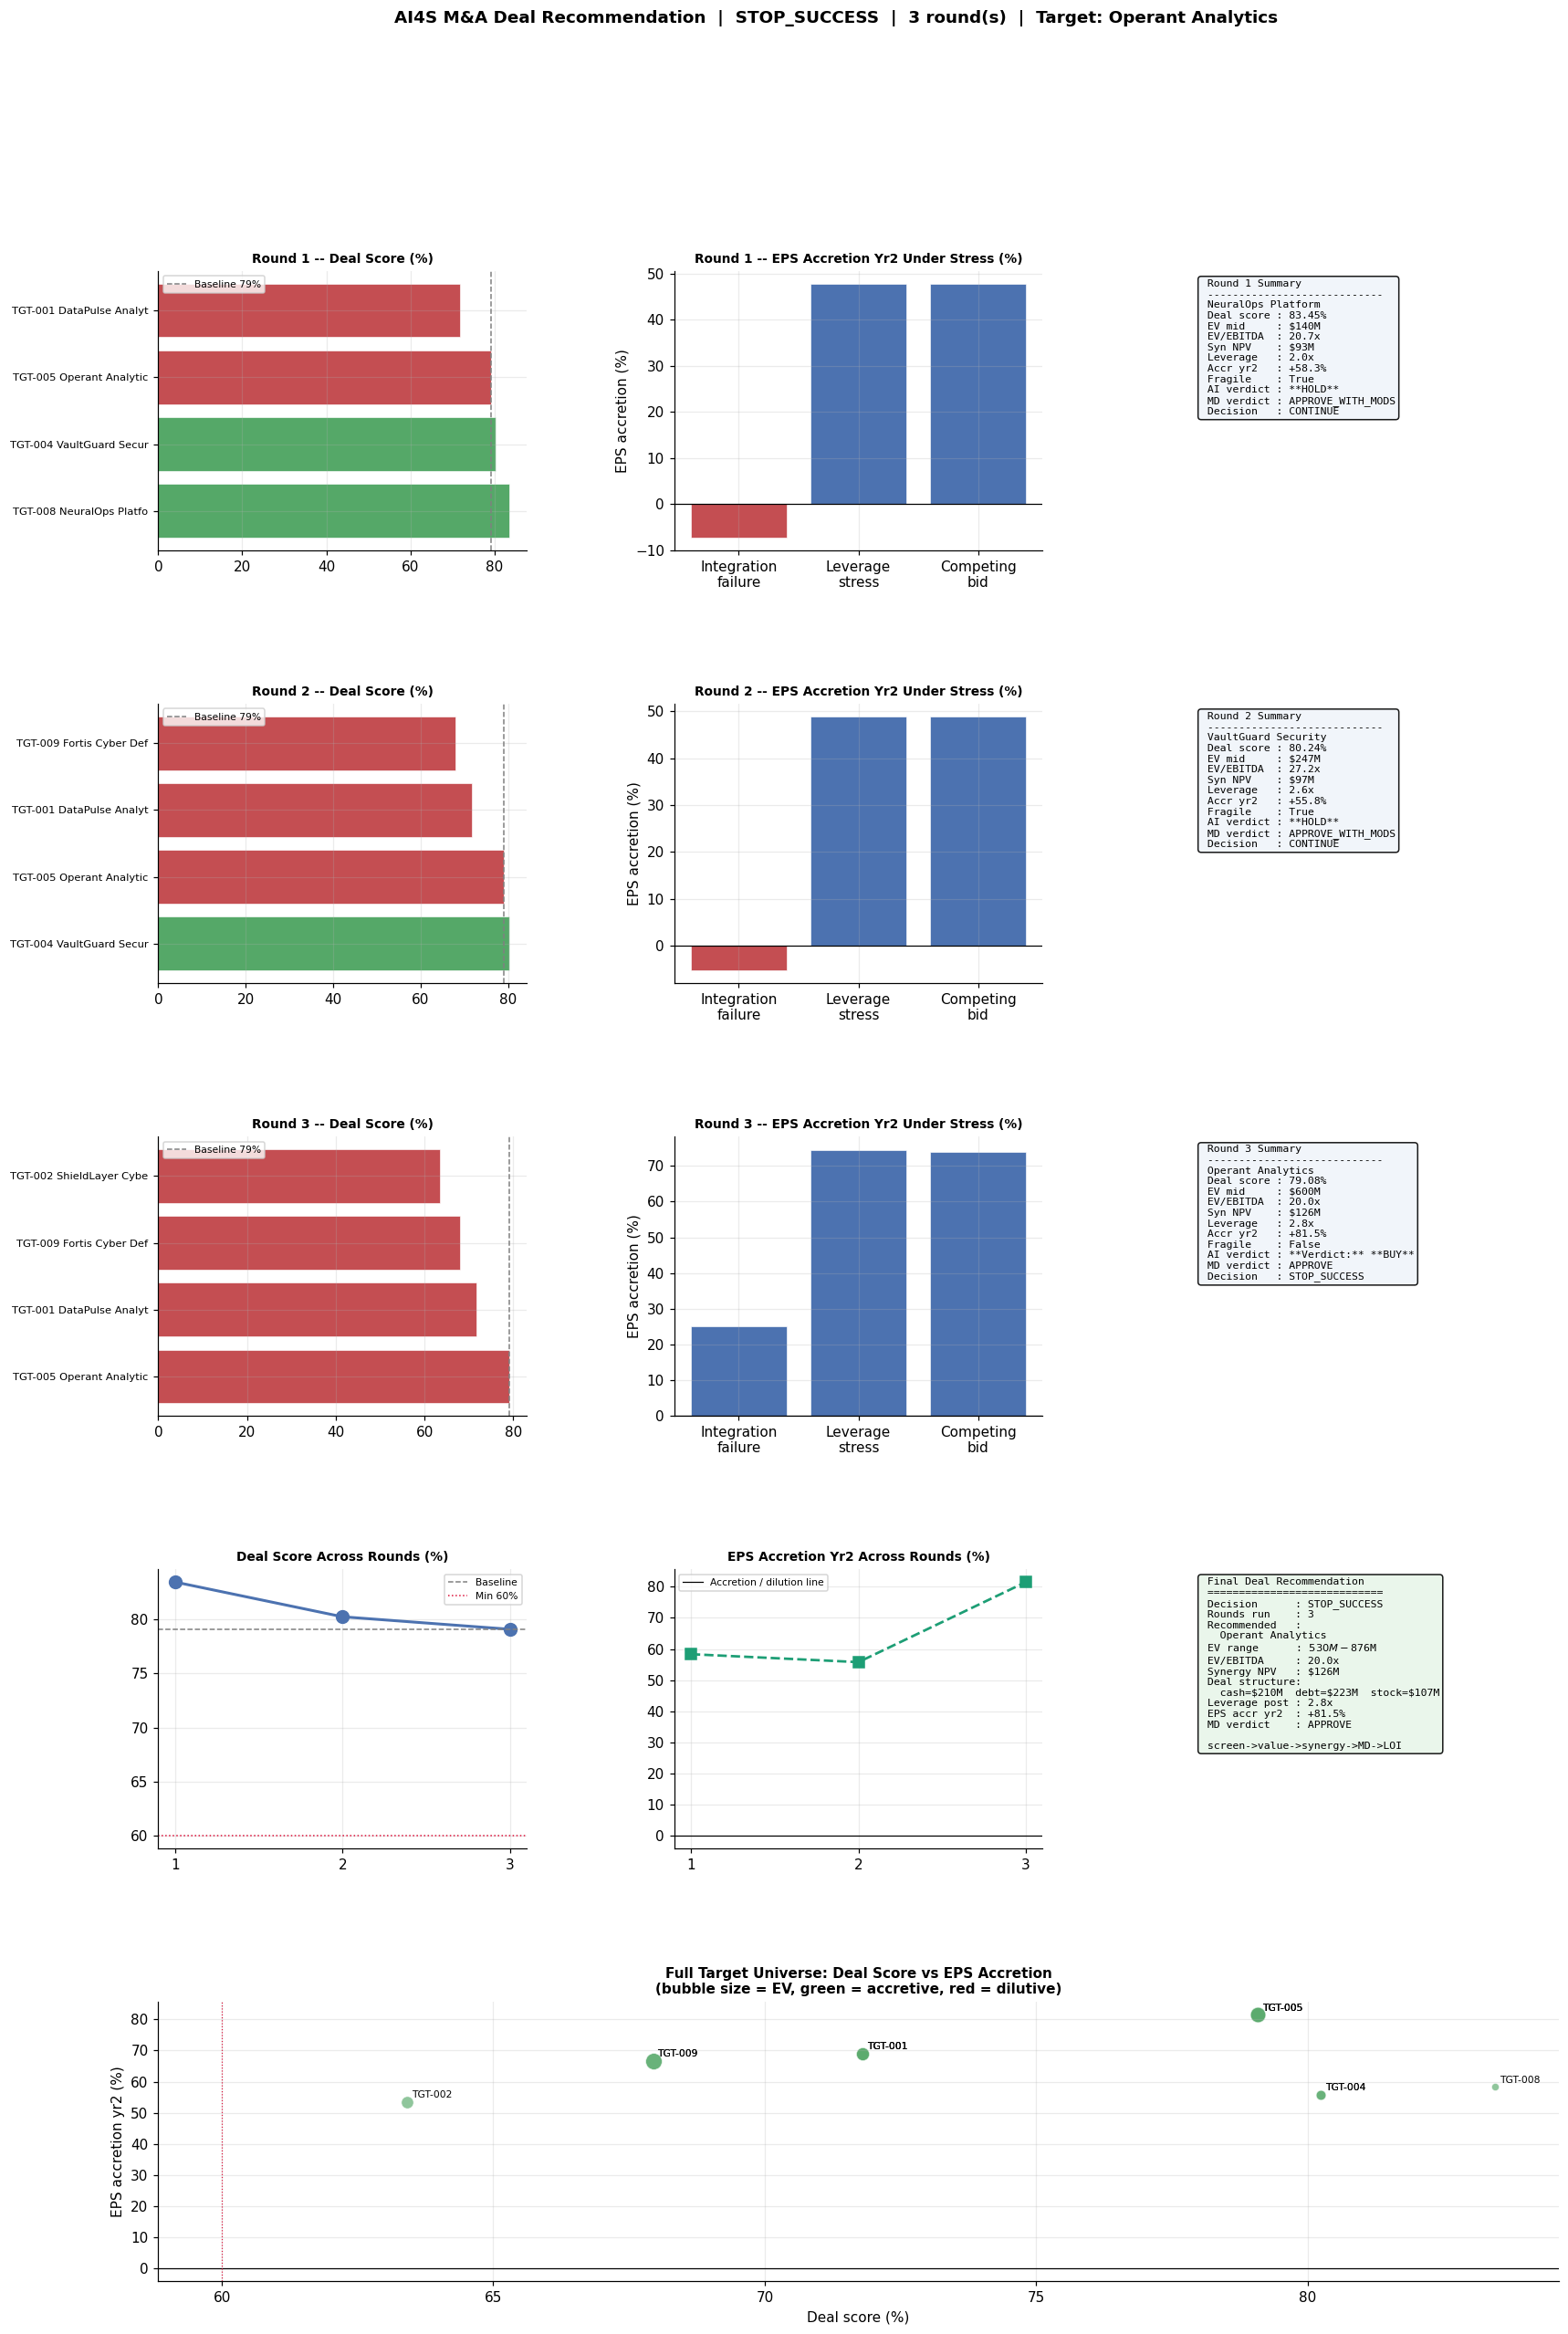


  BOARD MEMO -- Nexus Technology Corp

Key points for board presentation:
  > Deal within all constraints: leverage 2.8x, dilution 5.8%, $600M vs $800M cap
  > Year-2 EPS accretive at +81.5%; robust even under integration stress scenarios
  > 52% revenue overlap enables credible, conservative $126M synergy NPV projection

Negotiation tactics:
  >> Lock synergy clawbacks tied to yr2 EBITDA realization milestones
  >> Secure management retention agreements; 52% overlap demands seamless integration leadership


In [11]:
# CELL 10  FINAL DEAL RECOMMENDATION DASHBOARD
# -----------------------------------------------------------------------

n_rounds = len(agent.round_results)
fig = plt.figure(figsize=(18, 6 * n_rounds + 8))
gs  = gridspec.GridSpec(n_rounds + 2, 3, figure=fig,
                        hspace=0.55, wspace=0.40)

for ri, r in enumerate(agent.round_results):
    rev = agent.md_reviews[ri]    if ri < len(agent.md_reviews)    else {}
    dec = agent.decision_log[ri]  if ri < len(agent.decision_log)  else {}

    # deal score bar chart
    ax1 = fig.add_subplot(gs[ri, 0])
    names  = [a['shortlist']['target_id'] + ' ' + (a.get('target',{}).get('name','?')[:16])
              for a in r.deal_analyses]
    scores = [a['score'] for a in r.deal_analyses]
    bc     = ['#55A868' if s > baseline_dr.deal_score else '#C44E52' for s in scores]
    ax1.barh(names, [s*100 for s in scores],
             color=bc, edgecolor='white', linewidth=0.4)
    ax1.axvline(baseline_dr.deal_score*100, color='grey', ls='--', lw=1,
                label=f'Baseline {baseline_dr.deal_score:.0%}')
    ax1.set_title(f'Round {r.cycle_num} -- Deal Score (%)',
                  fontweight='bold', fontsize=9)
    ax1.tick_params(axis='y', labelsize=7.5)
    ax1.legend(fontsize=7)

    # stress test: EPS accretion under each scenario
    ax2 = fig.add_subplot(gs[ri, 1])
    sc_labels = ['Integration\nfailure', 'Leverage\nstress', 'Competing\nbid']
    sc_eps    = [r.stress_results.get(k,{}).get('eps_yr2',0)*100
                 for k in ['integration_failure','leverage_stress','competing_bid']]
    sc_colors = ['#4C72B0' if v > 0 else '#C44E52' for v in sc_eps]
    ax2.bar(sc_labels, sc_eps, color=sc_colors, edgecolor='white', linewidth=0.4)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_title(f'Round {r.cycle_num} -- EPS Accretion Yr2 Under Stress (%)',
                  fontweight='bold', fontsize=9)
    ax2.set_ylabel('EPS accretion (%)')

    # round summary
    ax3 = fig.add_subplot(gs[ri, 2])
    ax3.axis('off')
    deal    = r.best_deal
    fb_tag  = r.feedback_verdict.splitlines()[-1] if r.feedback_verdict else 'N/A'
    txt = '\n'.join([
        f' Round {r.cycle_num} Summary',
        ' ' + '-'*28,
        f' {r.best_target.get("name","?")[:28]}',
        f' Deal score : {(deal.deal_score if deal else 0):.2%}',
        f' EV mid     : ${(deal.ev_mid if deal else 0)/1e6:.0f}M',
        f' EV/EBITDA  : {(deal.implied_ev_ebitda if deal else 0):.1f}x',
        f' Syn NPV    : ${(deal.synergy_npv if deal else 0)/1e6:.0f}M',
        f' Leverage   : {(deal.leverage_ratio if deal else 0):.1f}x',
        f' Accr yr2   : {(deal.eps_accretion_yr2 if deal else 0):+.1%}',
        f' Fragile    : {r.fragile}',
        f' AI verdict : {fb_tag}',
        f' MD verdict : {rev.get("verdict","N/A")}',
        f' Decision   : {dec.get("decision","N/A")}',
    ])
    ax3.text(0.03, 0.97, txt, transform=ax3.transAxes,
             fontsize=7.5, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4fa', alpha=0.9))

# -- deal score evolution -----------------------------------------------
rounds  = [r.cycle_num for r in agent.round_results]
scores  = [r.best_deal.deal_score     if r.best_deal else 0 for r in agent.round_results]
epss    = [r.best_deal.eps_accretion_yr2 if r.best_deal else 0 for r in agent.round_results]

axS1 = fig.add_subplot(gs[n_rounds, 0])
axS1.plot(rounds, [s*100 for s in scores], 'o-', color='#4C72B0', lw=2, ms=9)
axS1.axhline(baseline_dr.deal_score*100, color='grey', ls='--', lw=1,
             label='Baseline')
axS1.axhline(agent.MIN_DEAL_SCORE*100, color='crimson', ls=':', lw=1,
             label=f'Min {agent.MIN_DEAL_SCORE:.0%}')
axS1.set_title('Deal Score Across Rounds (%)', fontweight='bold', fontsize=9)
axS1.set_xticks(rounds)
axS1.legend(fontsize=7)

axS2 = fig.add_subplot(gs[n_rounds, 1])
axS2.plot(rounds, [e*100 for e in epss], 's--', color='#1D9E75', lw=1.8, ms=8)
axS2.axhline(0, color='black', lw=0.8, label='Accretion / dilution line')
axS2.set_title('EPS Accretion Yr2 Across Rounds (%)', fontweight='bold', fontsize=9)
axS2.set_xticks(rounds)
axS2.legend(fontsize=7)

# -- valuation bridge for best deal ------------------------------------
axS3 = fig.add_subplot(gs[n_rounds, 2])
axS3.axis('off')
br   = best_result
bd   = br.best_deal
verdict_lines = [
    ' Final Deal Recommendation',
    ' ' + '='*28,
    f' Decision      : {agent.final_decision}',
    f' Rounds run    : {n_rounds}',
    f' Recommended   :',
    f'   {br.best_target.get("name","?")[:26]}',
    f' EV range      : ${(bd.ev_low if bd else 0)/1e6:.0f}M - ${(bd.ev_high if bd else 0)/1e6:.0f}M',
    f' EV/EBITDA     : {(bd.implied_ev_ebitda if bd else 0):.1f}x',
    f' Synergy NPV   : ${(bd.synergy_npv if bd else 0)/1e6:.0f}M',
    f' Deal structure:',
    f'   cash=${(bd.cash_component if bd else 0)/1e6:.0f}M  '
    f'debt=${(bd.new_debt if bd else 0)/1e6:.0f}M  '
    f'stock=${(bd.stock_component if bd else 0)/1e6:.0f}M',
    f' Leverage post : {(bd.leverage_ratio if bd else 0):.1f}x',
    f' EPS accr yr2  : {(bd.eps_accretion_yr2 if bd else 0):+.1%}',
    f' MD verdict    : {best_review.get("verdict","N/A")}',
    '',
    ' screen->value->synergy->MD->LOI',
]
axS3.text(0.03, 0.97, '\n'.join(verdict_lines),
          transform=axS3.transAxes, fontsize=7.5, va='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.9))

# -- target universe bubble chart: score vs EPS accretion --------------
axB = fig.add_subplot(gs[n_rounds+1, :])
for r in agent.round_results:
    for a in r.deal_analyses:
        if not a.get('deal'): continue
        d    = a['deal']
        t    = a.get('target',{})
        size = max(d.ev_mid / 5e6, 10)
        col  = '#55A868' if d.accretive_yr2 else '#C44E52'
        axB.scatter(d.deal_score*100, d.eps_accretion_yr2*100,
                    s=size, color=col, alpha=0.65, edgecolors='white', linewidth=0.5)
        axB.annotate(t.get('id','?'), (d.deal_score*100, d.eps_accretion_yr2*100),
                     xytext=(3,3), textcoords='offset points', fontsize=7)
axB.axhline(0, color='black', lw=0.8)
axB.axvline(agent.MIN_DEAL_SCORE*100, color='crimson', ls=':', lw=0.8)
axB.set_xlabel('Deal score (%)')
axB.set_ylabel('EPS accretion yr2 (%)')
axB.set_title('Full Target Universe: Deal Score vs EPS Accretion\n'
              '(bubble size = EV, green = accretive, red = dilutive)',
              fontweight='bold', fontsize=10)

fig.suptitle(
    f'AI4S M&A Deal Recommendation  |  {agent.final_decision}'
    f'  |  {n_rounds} round(s)  |  Target: {br.best_target.get("name","?")}',
    fontsize=12, fontweight='bold'
)
plt.savefig('ai4s_mna_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()

# -- Board memo -------------------------------------------------------
print('\n' + '='*58)
print('  BOARD MEMO -- Nexus Technology Corp')
print('='*58)
if best_review.get('board_presentation_points'):
    print('\nKey points for board presentation:')
    for p in best_review['board_presentation_points']:
        print(f'  > {p}')
if best_review.get('negotiation_recommendations'):
    print('\nNegotiation tactics:')
    for n in best_review['negotiation_recommendations']:
        print(f'  >> {n}')
if best_review.get('modifications'):
    print('\nRequired before submitting LOI:')
    for m in best_review['modifications']:
        print(f'  * {m}')

##3.CONCLUSION



Investment banking is the domain in this series where the numbers are largest,
the constraints are most numerous, and the cost of a wrong recommendation is
most immediately visible. A fairness opinion that cannot defend its synergy
assumptions, a deal structure that breaches the leverage covenant at close, an
EPS calculation that flips from accretive to dilutive when interest rates move
two hundred basis points — these are not academic errors. They are career-ending
ones. The AI4S framework does not make those errors impossible. What it does is
make the failure modes explicit before they reach a board presentation.

* What Was Built

The arithmetic engines — valuation, synergy modelling, deal structuring, accretion
analysis — are deterministic and produce bounded outputs. They are the quantitative
foundation. The AI layers operate on top of that foundation: generating shortlists,
screening for regulatory risk, stress-testing against integration failure and
competing bids, producing structured feedback, and governing the multi-round
search. Victoria Sands's review sits above all of it, applying the commercial
judgment that no model can replicate — whether the synergy assumptions are
defensible, whether the board will accept the leverage, whether the target's
management team will stay post-close.

* Synergy Scepticism Is Built In

The most common failure mode in M&A is not overpaying for the wrong target. It
is paying a correct-looking price for a target whose synergies never materialise
at the assumed rate. The system addresses this by anchoring synergy realisation
probability to comparable precedent transactions rather than to the model's
internal estimate alone, by stress-testing under a scenario where realisation
drops to thirty percent of projection, and by requiring Victoria to explicitly
scrutinise synergy assumptions as a condition of her review. A recommendation
that survives that scrutiny is one that has been stress-tested against the most
common way M&A creates negative value.

* The Board Is the Real Audience

Every output in this notebook — the deal score, the EPS accretion table, the
stress test results, the board presentation key points — is oriented toward
the moment when a human Managing Director presents a recommendation to a board
of directors who will ask hard questions. The AI4S loop is not the end of the
process. It is the preparation for that moment: a disciplined, evidence-grounded
search that produces a recommendation robust enough to survive challenge. The
board presentation points returned by Victoria's review are not decorative. They
are the stress test of the recommendation in a different domain — not numbers
under adverse scenarios but arguments under adversarial questioning.

* What Comes Next

The most immediate extension is replacing the synthetic target universe with a
live deal screener connected to actual financial data. The second is adding a
management quality assessment layer — a Claude call that reviews publicly
available information about the target's leadership team and culture. The third
is a post-merger integration tracker that closes the outer loop: comparing
projected synergies against actual post-close performance and feeding that
delta back into the next cycle's synergy assumptions.

The loop never really closes in M&A. Every deal produces data that should
inform the next one. What AI4S provides is the discipline to make that learning
explicit rather than tacit, and the architecture to act on it systematically.

